# Aggregate data in temporal dimensions

The `earthkit.transforms.temporal` sub-package simplifies the process of aggregating data in the temporal domains.
It can handle any data format that can `earthkit.data` can convert to xarray and will automatically detect the time
dimension to aggregate over.
This means a single workflow can be used for many different data formats.

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt

## Load some sample data

Load some sample gridded data from a remote grib file.

In [2]:
era5_europe_2015_gridded_data = ekd.from_source("url", "https://sites.ecmwf.int/repository/earthkit-data/test-data/era5_temperature_europe_2015.grib")
era5_europe_2015_gridded_data

path,/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/earthkit-data-edwardcomyn-platt/url-fcb8ec7e08771d4d53c3cc2db2568378075baf0b9661c6e6ceacb9111142e33e.grib
size,157.6 MiB
types,"fieldlist, pandas, xarray, numpy, array"


## Compute statistics over the entire time dimension

We can pass our file objects directly to the earthkit transforms methods, which will
detect the appropriate dimension and  compute the temporal statistic.

In [3]:
europe_mean_temperature = ekt.temporal.mean(era5_europe_2015_gridded_data)
europe_mean_temperature

<xarray.Dataset> Size: 456kB
Dimensions:    (latitude: 201, longitude: 281)
Coordinates:
  * latitude   (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
Data variables:
    2t         (latitude, longitude) float64 452kB 262.5 262.6 ... 297.4 294.4
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

The output is an `xarray.Dataset` object where the data is the mean of all time-steps in the original grib file.

We can plot this output directly with `earthkit-plots`.

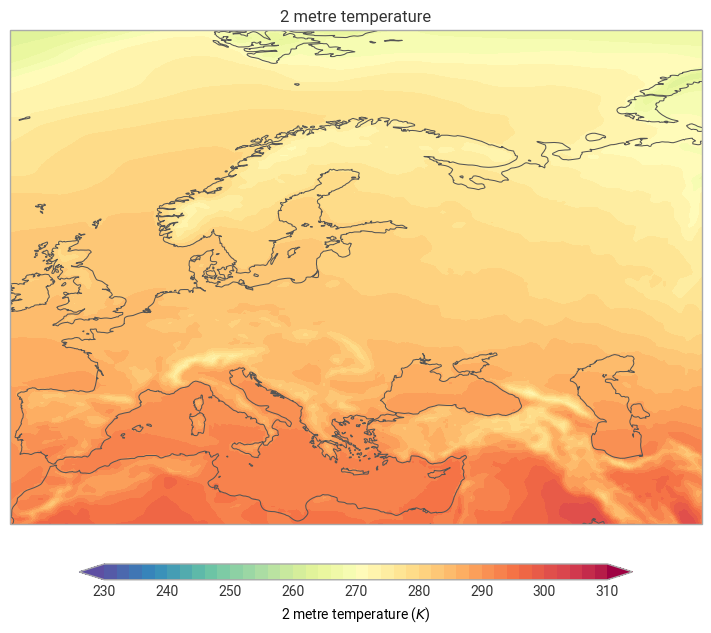

In [4]:
ekp.geo.plot(europe_mean_temperature)

A number of similar functions exist for calculating temporal statistics, e.g. `temporal.max`, `temporal.min`, `temporal.median`, `temporal.std` etc.

Additionally, there is general `temporal.reduce` functions which takes an argument `how` which can be any numpy function, or can be a bespoke function, as demonstrated below.

In [5]:
# Define a function, it must take an array axis which is the axis to apply the function along, i.e. the time axis
# earthkit-transforms and xarray will take care of the rest.
import numpy as np
import statsmodels.api as sm
def my_funky_function(x, axis=0, **kwargs):
    # Add a constant for the intercept
    X = sm.add_constant(np.arange(x.shape[axis]))
    _x = np.rollaxis(x, axis)
    _x_shape = _x.shape
    _x_flat = _x.reshape(_x_shape[0], -1)
    _out = np.zeros_like(_x_flat[0])
    for point in range(_x_flat.shape[1]):
        model = sm.OLS(_x_flat[:, point], X).fit()
        _out[point] = model.params[1]
    return _out.reshape(_x_shape[1:])

era5_trend = ekt.temporal.reduce(era5_europe_2015_gridded_data, how=my_funky_function, how_label="trend")

era5_trend["2t_trend"].attrs.update({"units": "K/(6 hr)", "long_name": "2 metre temperature trend"})

era5_trend

<xarray.Dataset> Size: 456kB
Dimensions:    (latitude: 201, longitude: 281)
Coordinates:
  * latitude   (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
Data variables:
    2t_trend   (latitude, longitude) float64 452kB 0.002469 0.00255 ... 0.001132
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

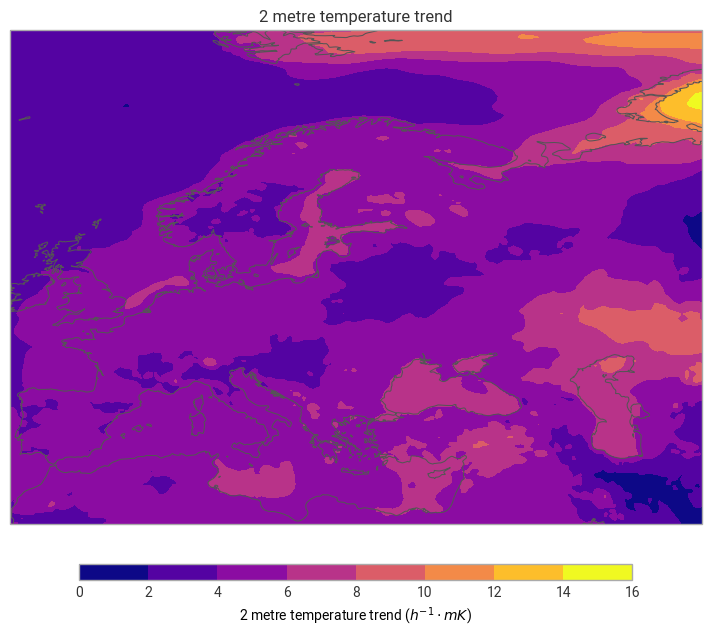

In [6]:
ekp.geo.plot(era5_trend, units="mK/hr")

## Appendix

The xarray representation of the raw grib file

In [7]:
era5_europe_2015_gridded_data.to_xarray()

<xarray.Dataset> Size: 660MB
Dimensions:                  (forecast_reference_time: 1460, latitude: 201,
                              longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 660MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## References

Refer to the [API Reference Guide](https://earthkit-transforms.readthedocs.io/en/latest/autodocs/earthkit.transforms.temporal.html#) for a complete list of the methods available.
